# Step2: Permana 2025スタイルの22特徴量への拡張

**前提**: このnotebookの前に、Step1 (MNE tutorialそのまま) のセルを実行し、
`epochs_train` (Alice) と `epochs_test` (Bob) が変数として存在していること。

**このnotebookで追加すること**:
- `src/features.py` に `extract_permana_features()` を追加 (新規関数、既存の`eeg_power_band`は無変更)
- 同じ `RandomForestClassifier(n_estimators=100, random_state=42)` で学習し、Step1と条件を揃えて比較する
- 変更点: 特徴量だけ (5個 → 22個)。分類器・train/testの分け方はStep1と同一。

**新規ライブラリ**: `antropy` (エントロピー計算), `pywavelets` (wavelet分解)


In [5]:
# 新規ライブラリのインストール (Step2で初めて必要になったもの)
!pip install antropy pywavelets -q


In [7]:
!pip install -q mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 28.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


## Step1データの読み込み (このnotebookを単体で実行できるようにするため追加)

**追加理由**: このnotebookを単体で開くと `epochs_train` / `epochs_test` が存在せず
`NameError` になるため。Step1 tutorialのデータ読み込みセルをそのまま (無変更で) ここに追加する。

**注意**: 中身はStep1で実行したコードと完全に同一。`eeg_power_band`の呼び出しはしていない
(Step1notebook側でのみ使う)ため、ここでは読み込みとepoch化までを行う。


In [8]:
import mne
from mne.datasets.sleep_physionet.age import fetch_data

ALICE, BOB = 0, 1
[alice_files, bob_files] = fetch_data(subjects=[ALICE, BOB], recording=[1])

annotation_desc_2_event_id = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3": 4,
    "Sleep stage 4": 4,
    "Sleep stage R": 5,
}
event_id = {
    "Sleep stage W": 1,
    "Sleep stage 1": 2,
    "Sleep stage 2": 3,
    "Sleep stage 3/4": 4,
    "Sleep stage R": 5,
}

# --- Alice (train) ---
raw_train = mne.io.read_raw_edf(
    alice_files[0], stim_channel="Event marker", infer_types=True,
    preload=True, verbose="error",
)
annot_train = mne.read_annotations(alice_files[1])
annot_train.crop(annot_train[1]["onset"] - 30 * 60, annot_train[-2]["onset"] + 30 * 60)
raw_train.set_annotations(annot_train, emit_warning=False)
events_train, _ = mne.events_from_annotations(
    raw_train, event_id=annotation_desc_2_event_id, chunk_duration=30.0
)
tmax = 30.0 - 1.0 / raw_train.info["sfreq"]
epochs_train = mne.Epochs(
    raw=raw_train, events=events_train, event_id=event_id,
    tmin=0.0, tmax=tmax, baseline=None,
)
del raw_train

# --- Bob (test) ---
raw_test = mne.io.read_raw_edf(
    bob_files[0], stim_channel="Event marker", infer_types=True,
    preload=True, verbose="error",
)
annot_test = mne.read_annotations(bob_files[1])
annot_test.crop(annot_test[1]["onset"] - 30 * 60, annot_test[-2]["onset"] + 30 * 60)
raw_test.set_annotations(annot_test, emit_warning=False)
events_test, _ = mne.events_from_annotations(
    raw_test, event_id=annotation_desc_2_event_id, chunk_duration=30.0
)
epochs_test = mne.Epochs(
    raw=raw_test, events=events_test, event_id=event_id,
    tmin=0.0, tmax=tmax, baseline=None,
)
del raw_test

print(epochs_train)
print(epochs_test)


Using default location ~/mne_data for PHYSIONET_SLEEP...
Creating /root/mne_data


  0%|                                              | 0.00/48.3M [00:00<?, ?B/s]

  0%|                                              | 0.00/4.62k [00:00<?, ?B/s]

  0%|                                              | 0.00/51.1M [00:00<?, ?B/s]

  0%|                                              | 0.00/3.90k [00:00<?, ?B/s]

Download complete in 06m48s (94.8 MB)
Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
Not setting metadata
841 matching events found
No baseline correction applied
0 projection items activated
Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
Not setting metadata
1103 matching events found
No baseline correction applied
0 projection items activated
<Epochs | 841 events (good & bad), 0 – 29.99 s (baseline off), ~10 KiB, data not loaded,
 'Sleep stage W': 188
 'Sleep stage 1': 58
 'Sleep stage 2': 250
 'Sleep stage 3/4': 220
 'Sleep stage R': 125>
<Epochs | 1103 events (good & bad), 0 – 29.99 s (baseline off), ~10 KiB, data not loaded,
 'Sleep stage W': 157
 'Sleep stage 1': 109
 'Sleep stage 2': 562
 'Sleep stage 

## `src/features.py` のインポート (GitHub管理版)

`src/features.py` はGitHubリポジトリ (`sleep-xai`) で管理しているため、
`%%writefile`は使わず、リポジトリをcloneしてimportする。

**変更点 (前バージョンからの差分)**:
- 削除: `%%writefile src/features.py` セル
- 追加: `git clone` でリポジトリを取得し、既存の `src/features.py` をそのままimportする方式
- `src/features.py` の中身自体は一切変更していません

⚠️ **リポジトリがprivateのため、このセルを実行する前に一時的にpublicに切り替えてください**
(GitHub → Settings → General → Danger Zone → Change repository visibility)。
実行後はprivateに戻して問題ありません。認証を使ったclone(SSH鍵 / Personal Access Token)は、
必要になったタイミングで改めて提案します。


In [9]:
# GitHubリポジトリをclone (src/features.py はこの中で管理されている)
# ※ 実行前にリポジトリを一時的にpublicにしておくこと (認証なしでcloneするため)
!git clone https://github.com/naokihayakawa1228/sleep-xai.git
%cd sleep-xai


Cloning into 'sleep-xai'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 22 (delta 9), reused 19 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 11.68 KiB | 1.67 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/sleep-xai/sleep-xai


In [10]:
import sys
sys.path.append(".")  # clone後にリポジトリのルートに%cd済みなら基本不要だが念のため

from src.features import eeg_power_band, extract_permana_features, PERMANA_FEATURE_NAMES

print("特徴量一覧 (22個):")
print(PERMANA_FEATURE_NAMES)


特徴量一覧 (22個):
['mean', 'variance', 'skewness', 'kurtosis', 'shannon_entropy', 'permutation_entropy', 'sample_entropy', 'spindle_count', 'kcomplex_count', 'ratio_theta_alpha', 'ratio_delta_beta', 'ratio_thetaalpha_beta', 'bp_delta', 'bp_theta', 'bp_alpha', 'bp_sigma', 'bp_beta', 'wavelet_energy_d1', 'wavelet_energy_d2', 'wavelet_energy_d3', 'wavelet_energy_d4', 'wavelet_energy_d5']


## 特徴量抽出 (Step1の`epochs_train`, `epochs_test`をそのまま再利用)

`eeg_power_band`をPSD経由で計算していたのに対し、`extract_permana_features`は
生波形からエポックごとにループして計算するため、少し時間がかかります
(841 + 1103エポックで数十秒〜数分程度が目安)。


In [11]:
X_train_p2 = extract_permana_features(epochs_train, verbose=True)
X_test_p2 = extract_permana_features(epochs_test, verbose=True)

print("X_train_p2.shape =", X_train_p2.shape)
print("X_test_p2.shape  =", X_test_p2.shape)


Using data from preloaded Raw for 841 events and 3000 original time points ...
0 bad epochs dropped
  200/841 エポック完了
  400/841 エポック完了
  600/841 エポック完了
  800/841 エポック完了
Using data from preloaded Raw for 1103 events and 3000 original time points ...
0 bad epochs dropped
  200/1103 エポック完了
  400/1103 エポック完了
  600/1103 エポック完了
  800/1103 エポック完了
  1000/1103 エポック完了
X_train_p2.shape = (841, 22)
X_test_p2.shape  = (1103, 22)


## 学習・評価 (Step1と同じRandomForest設定で比較)

Step1では `make_pipeline(FunctionTransformer(eeg_power_band), RandomForestClassifier(...))` を
使っていましたが、ここでは既に特徴量抽出済みの `X_train_p2` を直接学習に使います
(FunctionTransformerを介すると`extract_permana_features`が呼ばれるたびに再計算されて遅いため)。
分類器の設定 (`n_estimators=100, random_state=42`) はStep1と完全に揃えています。


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_train = epochs_train.events[:, 2]
y_test = epochs_test.events[:, 2]

clf_p2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_p2.fit(X_train_p2, y_train)
y_pred_p2 = clf_p2.predict(X_test_p2)

acc_p2 = accuracy_score(y_test, y_pred_p2)
print(f"Step2 (22特徴量) Accuracy: {acc_p2:.3f}")
print(f"(Step1 (5特徴量) Accuracy: 0.685 <- tutorialでの結果)")
print()
print(classification_report(y_test, y_pred_p2, target_names=event_id.keys()))
print(confusion_matrix(y_test, y_pred_p2))


Step2 (22特徴量) Accuracy: 0.754
(Step1 (5特徴量) Accuracy: 0.685 <- tutorialでの結果)

                 precision    recall  f1-score   support

  Sleep stage W       0.72      0.32      0.44       157
  Sleep stage 1       0.57      0.48      0.52       109
  Sleep stage 2       0.89      0.93      0.91       562
Sleep stage 3/4       0.52      0.90      0.66       105
  Sleep stage R       0.66      0.66      0.66       170

       accuracy                           0.75      1103
      macro avg       0.67      0.66      0.64      1103
   weighted avg       0.76      0.75      0.74      1103

[[ 50   6  11  74  16]
 [ 10  52  18   1  28]
 [  6   7 524  12  13]
 [  0   0  11  94   0]
 [  3  27  28   0 112]]


## 確認ポイント

- Step1 (0.685) と比べてAccuracyがどう変化したか
- どのステージのprecision/recallが改善/悪化したか
  (例: Stage 1の分類は難しいことが多いので、そこが伸びたかは要確認)
- 次のStep3 (RF vs XGBoost比較) に進む前に、この22特徴量の結果を記録しておく


In [13]:
!pip install shap -q

In [17]:
%cd /content/sleep-xai

# リモートの最新情報を取得
!git fetch origin

# shap_utils.pyだけ最新に更新
!git checkout origin/main -- src/shap_utils.py

/content/sleep-xai
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 8 (delta 5), reused 7 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 2.26 KiB | 330.00 KiB/s, done.
From https://github.com/naokihayakawa1228/sleep-xai
   050bfc2..2cd3804  main       -> origin/main


SHAP適用

In [27]:
import numpy as np

def normalize_shap_values(shap_values, n_classes, n_features):
    """常に (n_classes, n_samples, n_features) の形状に正規化する。"""
    if isinstance(shap_values, list):
        return np.stack(shap_values, axis=0)

    arr = np.asarray(shap_values)

    if arr.ndim == 2:
        return arr[None, ...]

    if arr.ndim == 3:
        shape = arr.shape
        if shape[0] == n_classes and shape[2] == n_features:
            return arr
        if shape[-1] == n_classes and shape[1] == n_features:
            return np.transpose(arr, (2, 0, 1))
        if shape[1] == n_classes and shape[2] == n_features:
            return np.transpose(arr, (1, 0, 2))

    raise ValueError(f"想定外のSHAP出力形状です: {arr.shape}")

In [31]:
import shap

explainer = shap.TreeExplainer(clf_p2)

shap_values_raw = explainer.shap_values(X_test_p2)

shap_values = normalize_shap_values(
    shap_values_raw,
    n_classes=len(event_id),
    n_features=X_test_p2.shape[1]
)

print(shap_values.shape)

(5, 1103, 22)


In [32]:
shap_n3 = shap_values[n3_idx]

セル3(Wake→N3誤分類の診断:ここが本題)

In [33]:
import pandas as pd

target_names = list(event_id.keys())
n3_idx = target_names.index("Sleep stage 3/4")

# 正解Wake・予測N3(誤分類) と 正解Wake・予測Wake(正しい) を比較
mis_idx = np.where((y_test == 1) & (y_pred_p2 == 4))[0]
correct_idx = np.where((y_test == 1) & (y_pred_p2 == 1))[0]
print(f"Wake→N3 誤分類: {len(mis_idx)}件 / 正しくWake: {len(correct_idx)}件")

shap_n3 = shap_values[n3_idx]  # N3クラスへのSHAP値, shape (n_test, 22)

df_compare = pd.DataFrame({
    "feature": PERMANA_FEATURE_NAMES,
    "mean_shap_誤分類(Wake→N3)": shap_n3[mis_idx].mean(axis=0),
    "mean_shap_正解Wake": shap_n3[correct_idx].mean(axis=0),
})
df_compare["diff"] = df_compare["mean_shap_誤分類(Wake→N3)"] - df_compare["mean_shap_正解Wake"]
df_compare.sort_values("diff", ascending=False)

Wake→N3 誤分類: 74件 / 正しくWake: 50件


,feature,mean_shap_誤分類(Wake→N3),mean_shap_正解Wake,diff
10,ratio_delta_beta,1.064547e-01,-0.019351,1.258055e-01
16,bp_beta,7.890538e-02,-0.006563,8.546811e-02
1,variance,1.030228e-01,0.033786,6.923709e-02
5,permutation_entropy,-3.397466e-02,-0.089549,5.557475e-02
21,wavelet_energy_d5,4.598905e-02,-0.001708,4.769730e-02
11,ratio_thetaalpha_beta,1.908780e-03,-0.031823,3.373132e-02
20,wavelet_energy_d4,1.514635e-02,-0.004897,2.004361e-02
6,sample_entropy,3.598731e-02,0.015979,2.000880e-02
13,bp_theta,1.649539e-02,0.004200,1.229519e-02
4,shannon_entropy,-3.655555e-03,-0.015031,1.137572e-02


セル4(Global重要度も一応可視化)

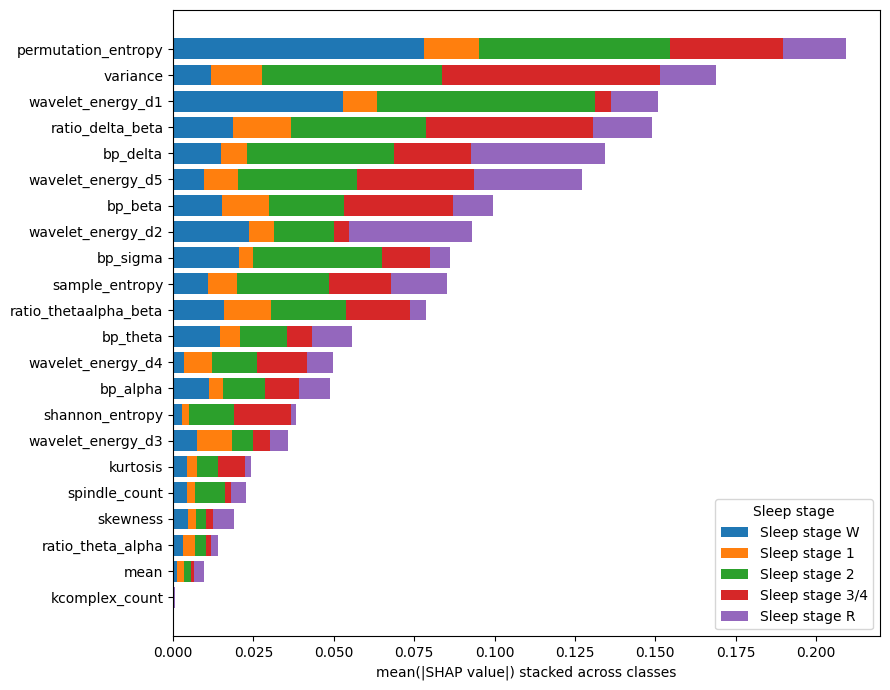

In [34]:
import matplotlib.pyplot as plt

mean_abs_shap = np.mean(np.abs(shap_values), axis=1)  # (n_classes, n_features)
order = np.argsort(mean_abs_shap.mean(axis=0))[::-1]

fig, ax = plt.subplots(figsize=(9, 7))
bottom = np.zeros(len(PERMANA_FEATURE_NAMES))
x_pos = np.arange(len(PERMANA_FEATURE_NAMES))
for ci, cname in enumerate(target_names):
    vals = mean_abs_shap[ci, order]
    ax.barh(x_pos, vals, left=bottom[order] if ci > 0 else None, label=cname)
    bottom += mean_abs_shap[ci] if ci > 0 else mean_abs_shap[ci]
ax.set_yticks(x_pos); ax.set_yticklabels([PERMANA_FEATURE_NAMES[i] for i in order])
ax.invert_yaxis()
ax.set_xlabel("mean(|SHAP value|) stacked across classes")
ax.legend(title="Sleep stage", loc="lower right")
plt.tight_layout()
plt.show()